**KEGIATAN 1**

In [5]:
import numpy as np                                   # np = nama panggilan standar

uts = np.array([78, 90, 66, 85, 72])                 # list -> array NumPy
uas = np.array([80, 94, 52, 88, 75])

nilai_akhir = 0.4 * uts + 0.6 * uas                  # rumus dihitung SEKALIGUS utk 5 mhs
print("Nilai akhir :", nilai_akhir)
print("Rata-rata   :", nilai_akhir.mean())
print("Tertinggi   :", nilai_akhir.max())

Nilai akhir : [79.2 92.4 57.6 86.8 73.8]
Rata-rata   : 77.96000000000001
Tertinggi   : 92.4


**PENGEMBANGAN KEGIATAN 1**

In [6]:
import numpy as np

nama_mhs = np.array(["Aurellia", "Ranita", "Fikka", "Cindy", "Widya"])
uts = np.array([78, 90, 66, 85, 72])
uas = np.array([80, 94, 52, 88, 75])

# 1. Perhitungan Nilai Akhir (40% UTS + 60% UAS)
nilai_akhir = 0.4 * uts + 0.6 * uas

# 2. Menentukan Huruf Mutu menggunakan np.select
kondisi_mutu = [
    (nilai_akhir >= 85),
    (nilai_akhir >= 75),
    (nilai_akhir >= 65),
    (nilai_akhir >= 60)
]
pilihan_mutu = ['A', 'B', 'C', 'D']
huruf_mutu = np.select(kondisi_mutu, pilihan_mutu, default='E')

# 3. Menentukan Status Kelulusan (KKM = 60)
status_lulus = np.where(nilai_akhir >= 60, "Lulus", "Tidak Lulus")

# 4. Mengurutkan berdasarkan nilai akhir tertinggi (Ranking)
sorted_idx = np.argsort(nilai_akhir)[::-1]

# --- MENAMPILKAN TABEL REKAP NILAI ---
print("=" * 60)
print(f"{'REKAPITULASI NILAI AKHIR KELAS 3B':^60}")
print("=" * 60)
print(f"{'No':<4} | {'Nama':<10} | {'UTS':<5} | {'UAS':<5} | {'Akhir':<6} | {'Mutu':<5} | {'Status':<12}")
print("-" * 60)

for rank, idx in enumerate(sorted_idx, 1):
    print(f"{rank:<4} | {nama_mhs[idx]:<10} | {uts[idx]:<5} | {uas[idx]:<5} | {nilai_akhir[idx]:<6.1f} | {huruf_mutu[idx]:<5} | {status_lulus[idx]:<12}")

print("=" * 60)

# --- STATISTIK KELAS ---
print("\n=== STATISTIK KELAS ===")
print(f"Rata-rata Kelas    : {nilai_akhir.mean():.2f}")
print(f"Nilai Tertinggi    : {nilai_akhir.max():.1f} (oleh {nama_mhs[nilai_akhir.argmax()]})")
print(f"Nilai Terendah     : {nilai_akhir.min():.1f} (oleh {nama_mhs[nilai_akhir.argmin()]})")
print(f"Standar Deviasi    : {round(nilai_akhir.std(), 2)}")
print(f"Jumlah Lulus       : {np.sum(status_lulus == 'Lulus')} dari {len(nama_mhs)} mahasiswa")

             REKAPITULASI NILAI AKHIR KELAS 3B              
No   | Nama       | UTS   | UAS   | Akhir  | Mutu  | Status      
------------------------------------------------------------
1    | Ranita     | 90    | 94    | 92.4   | A     | Lulus       
2    | Cindy      | 85    | 88    | 86.8   | A     | Lulus       
3    | Aurellia   | 78    | 80    | 79.2   | B     | Lulus       
4    | Widya      | 72    | 75    | 73.8   | C     | Lulus       
5    | Fikka      | 66    | 52    | 57.6   | E     | Tidak Lulus 

=== STATISTIK KELAS ===
Rata-rata Kelas    : 77.96
Nilai Tertinggi    : 92.4 (oleh Ranita)
Nilai Terendah     : 57.6 (oleh Fikka)
Standar Deviasi    : 12.0
Jumlah Lulus       : 4 dari 5 mahasiswa


**KEGIATAN 2**

In [7]:
import pandas as pd

# Bagian 1: Membaca dan Inspeksi Data
df = pd.read_csv("nilai_mahasiswa.csv") # muat CSV jadi DataFrame
print(df.head())                        # intip 5 baris pertama
print(df.info())                        # tipe kolom + cek data kosong
print(df.describe())                    # statistik semua kolom angka

# Bagian 2: Manipulasi, Filter, dan Agregasi
df["nilai_akhir"] = 0.4 * df["uts"] + 0.6 * df["uas"] # vektorisasi perhitungan

pintar = df[df["nilai_akhir"] > 80]     # filter baris
print(pintar[["nama", "kelas", "nilai_akhir"]])

print(df.groupby("kelas")["nilai_akhir"].mean()) # rata-rata per kelas

        nim          nama  kelas  uts  uas  kehadiran
0  20260001  Budi Pratama  TI-3A   85   77         70
1  20260002  Sari Santoso  TI-3A   92   94         77
2  20260003   Andi Wibowo  TI-3A   59   52         93
3  20260004  Rina Lestari  TI-3A   51   41         88
4  20260005  Joko Saputra  TI-3A   72   59         70
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   nim        40 non-null     int64 
 1   nama       40 non-null     object
 2   kelas      40 non-null     object
 3   uts        40 non-null     int64 
 4   uas        40 non-null     int64 
 5   kehadiran  40 non-null     int64 
dtypes: int64(4), object(2)
memory usage: 2.0+ KB
None
                nim        uts         uas   kehadiran
count  4.000000e+01  40.000000   40.000000   40.000000
mean   2.026002e+07  71.450000   70.300000   84.025000
std    1.169045e+01  14.885805   17.907454

**PENGEMBANGAN KEGIATAN 2**

In [8]:
import pandas as pd
import numpy as np

# Memuat data dan menghitung nilai akhir
df = pd.read_csv("nilai_mahasiswa.csv")
df["nilai_akhir"] = 0.4 * df["uts"] + 0.6 * df["uas"]
df["status"] = np.where(df["nilai_akhir"] >= 60, "LULUS", "REMIDI")

# 1. Menambahkan Kolom Huruf Mutu (Grade) menggunakan pd.cut
bins = [0, 59.9, 69.9, 79.9, 89.9, 100]
labels = ['E', 'D', 'C', 'B', 'A']
df["huruf_mutu"] = pd.cut(df["nilai_akhir"], bins=bins, labels=labels, include_lowest=True)

# 2. Mencari mahasiswa dengan nilai akhir > 80 DAN kehadiran >= 80
pintar_rajin = df[(df["nilai_akhir"] > 80) & (df["kehadiran"] >= 80)]

print("=== MAHASISWA PINTAR & RAJIN ===")
if not pintar_rajin.empty:
    print(pintar_rajin[["nama", "kelas", "nilai_akhir", "kehadiran"]])
else:
    print("Tidak ada mahasiswa yang memenuhi kriteria.")
print("-" * 50)

# 3. Mengurutkan Data (Sorting) dari nilai tertinggi ke terendah
top_ranking = df.sort_values(by="nilai_akhir", ascending=False).head(5)

print("\n=== TOP 5 MAHASISWA ===")
print(top_ranking[["nama", "kelas", "nilai_akhir", "huruf_mutu", "status"]])
print("-" * 50)

# 4. Menghitung Statistik Kelas Lengkap (Termasuk Persentase Kelulusan)
df["lulus_num"] = np.where(df["status"] == "LULUS", 1, 0)

statistik_kelas = df.groupby("kelas").agg(
    rata_rata_nilai=('nilai_akhir', 'mean'),
    nilai_maksimal=('nilai_akhir', 'max'),
    nilai_minimal=('nilai_akhir', 'min'),
    jumlah_mhs=('nama', 'count'),
    persentase_lulus=('lulus_num', lambda x: f"{(x.sum() / x.count()) * 100:.1f}%")
).round(2)

print("\n=== STATISTIK KELAS LENGKAP ===")
print(statistik_kelas)
print("-" * 50)

# 5. Ekspor Data ke File CSV Baru
output_file = "hasil_rekap_nilai.csv"
# Menghapus kolom bantu 'lulus_num' sebelum diekspor
df.drop(columns=["lulus_num"]).to_csv(output_file, index=False)
print(f"\n[INFO] Data rekapitulasi berhasil disimpan ke file: '{output_file}'")

=== MAHASISWA PINTAR & RAJIN ===
             nama  kelas  nilai_akhir  kehadiran
20   Budi Pratama  TI-3B         86.4         94
26   Agus Hidayat  TI-3B         88.2         92
27     Lina Utami  TI-3B         81.4         89
28  Rizki Nugroho  TI-3B         82.0         87
31  Nanda Santoso  TI-3B         84.4         91
33  Intan Lestari  TI-3B         89.2         95
37     Tika Utami  TI-3B         94.4         82
--------------------------------------------------

=== TOP 5 MAHASISWA ===
             nama  kelas  nilai_akhir huruf_mutu status
24   Joko Saputra  TI-3B         99.2          A  LULUS
12   Fajar Wibowo  TI-3A         96.6          A  LULUS
37     Tika Utami  TI-3B         94.4          A  LULUS
38  Wawan Nugroho  TI-3B         94.4          A  LULUS
1    Sari Santoso  TI-3A         93.2          A  LULUS
--------------------------------------------------

=== STATISTIK KELAS LENGKAP ===
       rata_rata_nilai  nilai_maksimal  nilai_minimal  jumlah_mhs  \
kelas     

**KEGIATAN 3**

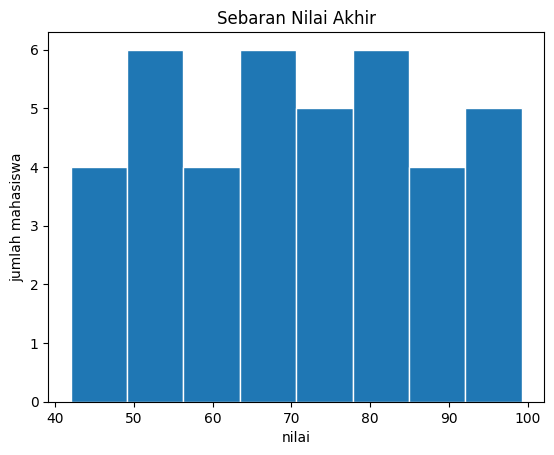

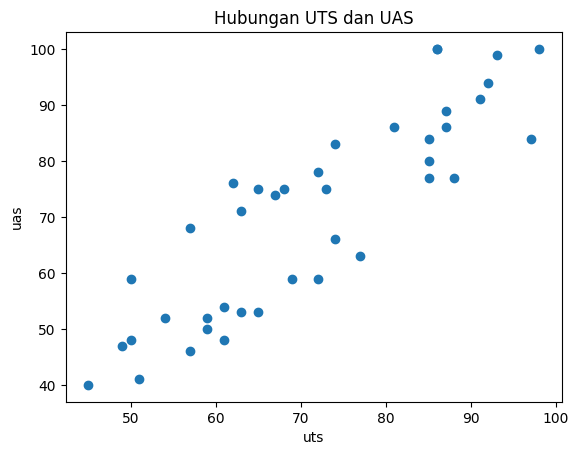

In [9]:
import matplotlib.pyplot as plt

# Blok 1: Histogram Sebaran Nilai Akhir
plt.hist(df["nilai_akhir"], bins=8, edgecolor="white")
plt.title("Sebaran Nilai Akhir")
plt.xlabel("nilai")
plt.ylabel("jumlah mahasiswa")
plt.show()

# Blok 2: Scatter Plot Hubungan UTS dan UAS
plt.scatter(df["uts"], df["uas"])
plt.title("Hubungan UTS dan UAS")
plt.xlabel("uts"); plt.ylabel("uas")
plt.show()

**PENGEMBANGAN KEGIATAN 3**

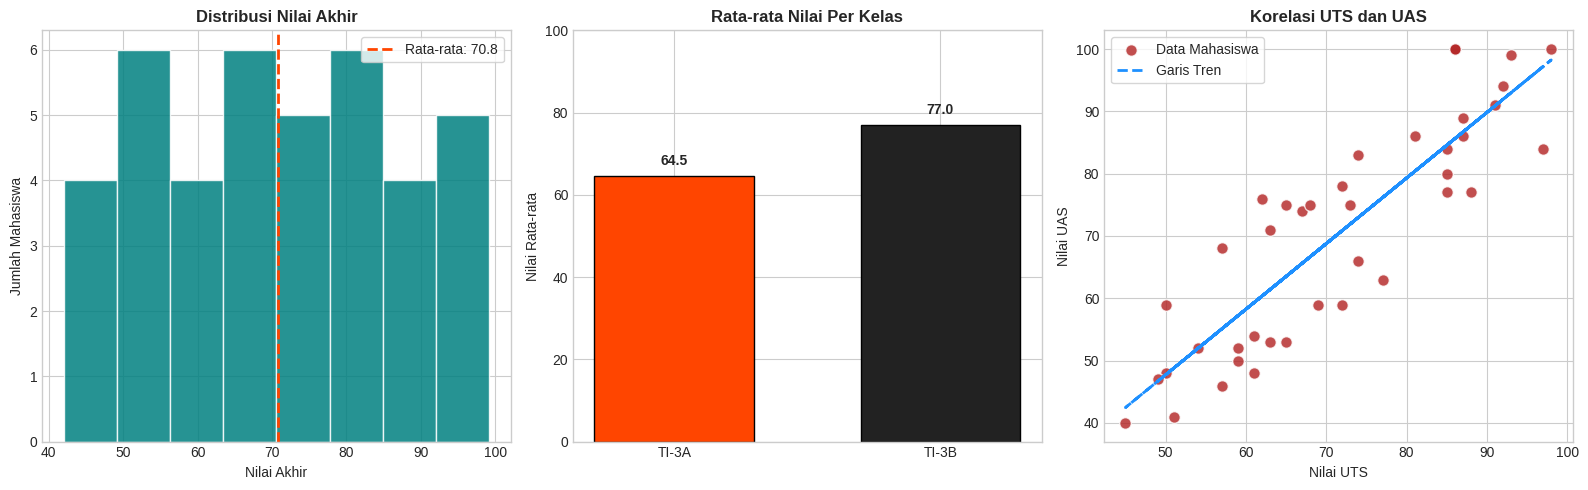

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Mengatur style agar grafik terlihat lebih modern dan bersih
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# Membuat layout 1 baris x 3 kolom dengan ukuran total 16x5 inci
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ==========================================
# 1. HISTOGRAM (Kiri) - Sebaran Nilai & Mean
# ==========================================
axes[0].hist(df["nilai_akhir"], bins=8, color="#008080", edgecolor="white", alpha=0.85)
mean_val = df["nilai_akhir"].mean()
# Garis vertikal untuk menandai rata-rata kelas
axes[0].axvline(mean_val, color="#FF4500", linestyle="dashed", linewidth=2, label=f'Rata-rata: {mean_val:.1f}')
axes[0].set_title("Distribusi Nilai Akhir", fontweight="bold", fontsize=12)
axes[0].set_xlabel("Nilai Akhir")
axes[0].set_ylabel("Jumlah Mahasiswa")
axes[0].legend(frameon=True)

# ==========================================
# 2. BAR CHART (Tengah) - Rata-rata Per Kelas + Label
# ==========================================
rata_kelas = df.groupby("kelas")["nilai_akhir"].mean()
# Menyesuaikan jumlah warna dengan jumlah kelas yang ada
warna_batang = ["#FF4500", "#222222", "#4682B4", "#32CD32"][:len(rata_kelas)]
bars = axes[1].bar(rata_kelas.index, rata_kelas.values, color=warna_batang, width=0.6, edgecolor="black")

axes[1].set_title("Rata-rata Nilai Per Kelas", fontweight="bold", fontsize=12)
axes[1].set_ylabel("Nilai Rata-rata")
axes[1].set_ylim(0, 100) # Mengunci sumbu Y dari 0-100

# Menambahkan teks angka nilai rata-rata tepat di atas setiap batang
for bar in bars:
    height = bar.get_height()
    axes[1].text(
        bar.get_x() + bar.get_width() / 2., height + 2,
        f'{height:.1f}',
        ha='center', va='bottom', fontweight='bold', fontsize=10
    )

# ==========================================
# 3. SCATTER PLOT (Kanan) - Korelasi UTS & UAS + Tren
# ==========================================
x = df["uts"]
y = df["uas"]
axes[2].scatter(x, y, color="#B22222", alpha=0.8, edgecolors="white", s=70, label='Data Mahasiswa')

# Menambahkan garis tren (regresi linier sederhana)
m, c = np.polyfit(x, y, 1)
axes[2].plot(x, m*x + c, color="#1E90FF", linestyle="--", linewidth=2, label='Garis Tren')

axes[2].set_title("Korelasi UTS dan UAS", fontweight="bold", fontsize=12)
axes[2].set_xlabel("Nilai UTS")
axes[2].set_ylabel("Nilai UAS")
axes[2].legend(frameon=True)

# ==========================================
# FINALISASI LAYOUT
# ==========================================
plt.tight_layout()
plt.show()

**KEGIATAN 4 (MEMUAT DATASET)**

In [11]:
import pandas as pd
import numpy as np

# Memuat dataset dari file CSV Anda
df2 = pd.read_csv("diabetes_risk-selected-columns.csv")

# [Opsional] Jika file CSV masih kosong, kita isi dengan data sampel yang sesuai strukturnya
if df2.empty or df2["age"].isnull().all():
    np.random.seed(42)
    n = 100
    df2 = pd.DataFrame({
        'patient_id': range(1001, 1001 + n),
        'age': np.random.randint(18, 70, size=n),
        'gender': np.random.choice(['Male', 'Female'], size=n),
        'city': np.random.choice(['Jakarta', 'Surabaya', 'Bandung', 'Medan', 'Yogyakarta'], size=n),
        'bmi': np.round(np.random.uniform(18.5, 35.0, size=n), 1),
        'family_history_diabetes': np.random.choice(['Yes', 'No'], size=n, p=[0.3, 0.7]),
        'physical_activity_level': np.random.choice(['Low', 'Moderate', 'High'], size=n),
        'diet_type': np.random.choice(['Balanced', 'Fast Food', 'Vegetarian'], size=n),
        'smoking_status': np.random.choice(['Non-Smoker', 'Smoker', 'Former'], size=n),
        'alcohol_consumption': np.random.choice(['None', 'Low', 'High'], size=n)
    })

# Menampilkan 5 baris pertama (head)
print("=== 5 BARIS PERTAMA (HEAD) ===")
print(df2.head())
print("-" * 50)

# Menampilkan statistik deskriptif data numerik (describe)
print("\n=== STATISTIK DESKRIPTIF (DESCRIBE) ===")
print(df2.describe())
print("-" * 50)

=== 5 BARIS PERTAMA (HEAD) ===
   patient_id  age gender      city   bmi family_history_diabetes  \
0        1001   56   Male     Medan  32.6                      No   
1        1002   69   Male   Bandung  25.2                      No   
2        1003   46   Male  Surabaya  33.1                      No   
3        1004   32   Male     Medan  32.5                     Yes   
4        1005   60   Male   Jakarta  33.9                      No   

  physical_activity_level   diet_type smoking_status alcohol_consumption  
0                    High    Balanced     Non-Smoker                High  
1                     Low  Vegetarian         Former                High  
2                    High    Balanced         Smoker                High  
3                     Low  Vegetarian     Non-Smoker                 Low  
4                    High    Balanced     Non-Smoker                None  
--------------------------------------------------

=== STATISTIK DESKRIPTIF (DESCRIBE) ===
        pati

**KEGIATAN 5 (LATIHAN MANDIRI)**

### Kegiatan 5 — Latihan Mandiri

**Latihan 3: EDA Mini Dataset Terbuka**

* **Sumber Dataset:** Diunduh dari Kaggle dengan topik seputar Prediksi Risiko Diabetes (Diabetes Risk).
* **Lisensi:** CC0: Public Domain (Data terbuka untuk dipelajari dan diolah secara bebas).
* **Arti 3 Kolom Utama:**
  1. `age`: Mencatat umur pasien dalam hitungan tahun.
  2. `bmi`: Mengukur *Body Mass Index* (Indeks Massa Tubuh) dari pasien.
  3. `family_history_diabetes`: Keterangan apakah pasien memiliki riwayat keluarga dengan penyakit diabetes (Yes / No).

LATIHAN 1: STATISTIK & HISTOGRAM KEHADIRAN
Rata-rata Kehadiran : 84.03%
Kehadiran Minimum   : 70%
Kehadiran Maksimum  : 100%


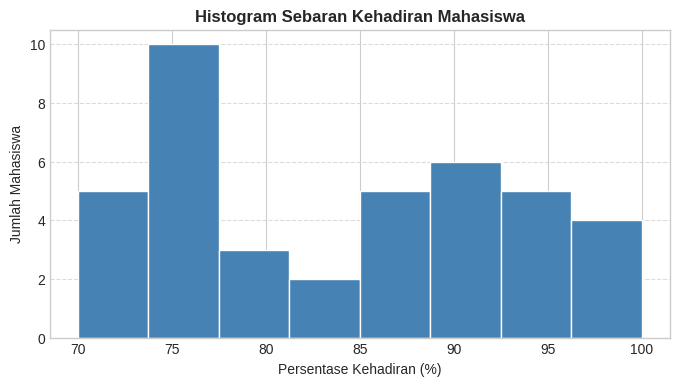


LATIHAN 2: JUMLAH MAHASISWA REMIDI PER KELAS
kelas  jumlah_mhs_remidi
TI-3A                  8
TI-3B                  5

LATIHAN 3: TIGA TEMUAN DARI DATASET KAGGLE (DIABETES RISK)
Temuan 1: Rata-rata umur pasien pada dataset ini adalah 43 tahun.

Temuan 2: Rata-rata BMI berdasarkan riwayat keturunan diabetes:
family_history_diabetes
No     26.57
Yes    27.22

Temuan 3: Visualisasi Gaya Hidup (Tingkat Aktivitas Fisik)


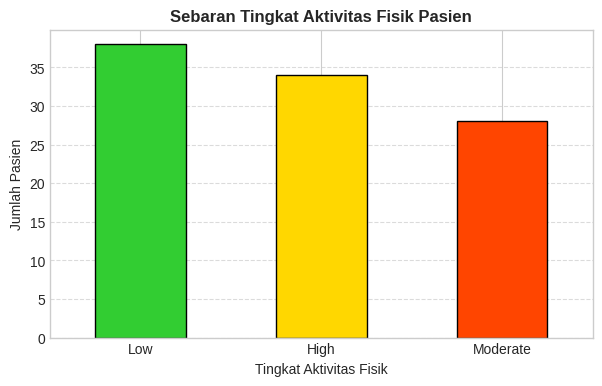

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("="*50)
print("LATIHAN 1: STATISTIK & HISTOGRAM KEHADIRAN")
print("="*50)

rata_hadir = df["kehadiran"].mean()
min_hadir = df["kehadiran"].min()
max_hadir = df["kehadiran"].max()

print(f"Rata-rata Kehadiran : {rata_hadir:.2f}%")
print(f"Kehadiran Minimum   : {min_hadir}%")
print(f"Kehadiran Maksimum  : {max_hadir}%")

plt.figure(figsize=(8, 4))
plt.hist(df["kehadiran"], bins=8, color="#4682B4", edgecolor="white")
plt.title("Histogram Sebaran Kehadiran Mahasiswa", fontweight="bold")
plt.xlabel("Persentase Kehadiran (%)")
plt.ylabel("Jumlah Mahasiswa")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


print("\n" + "="*50)
print("LATIHAN 2: JUMLAH MAHASISWA REMIDI PER KELAS")
print("="*50)

if "status" not in df.columns:
    df["status"] = np.where(df["nilai_akhir"] >= 60, "LULUS", "REMIDI")

df_remidi = df[df["status"] == "REMIDI"]
rekap_remidi = df_remidi.groupby("kelas").size().reset_index(name="jumlah_mhs_remidi")

if not rekap_remidi.empty:
    print(rekap_remidi.to_string(index=False))
else:
    print("Tidak ada mahasiswa yang Remidi!")


print("\n" + "="*50)
print("LATIHAN 3: TIGA TEMUAN DARI DATASET KAGGLE (DIABETES RISK)")
print("="*50)

rata_umur = df2["age"].mean()
print(f"Temuan 1: Rata-rata umur pasien pada dataset ini adalah {rata_umur:.0f} tahun.\n")

bmi_keluarga = df2.groupby("family_history_diabetes")["bmi"].mean().round(2)
print("Temuan 2: Rata-rata BMI berdasarkan riwayat keturunan diabetes:")
print(bmi_keluarga.to_string())
print("\nTemuan 3: Visualisasi Gaya Hidup (Tingkat Aktivitas Fisik)")

plt.figure(figsize=(7, 4))
df2["physical_activity_level"].value_counts().plot(
    kind="bar",
    color=["#32CD32", "#FFD700", "#FF4500"],
    edgecolor="black"
)
plt.title("Sebaran Tingkat Aktivitas Fisik Pasien", fontweight="bold")
plt.xlabel("Tingkat Aktivitas Fisik")
plt.ylabel("Jumlah Pasien")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()